# Example of Agnostic Benchmark application on Regression Task

In [2]:
import os, warnings
import numpy as np
import time

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings("ignore")
CUDA_VISIBLE_DEVICES=""
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import sys
sys.path.insert(0,'../../uqmodels/abench')
sys.path.insert(0,'../../n5_uqmodels/')
sys.path.insert(0,'src/')
import abench
import uqmodels

from abench.store import api
from src.metric import base_rmse,ABMetricGeneric
from abench.benchmark.benchmark import compute_metrics_on_dataloader,perf_agg_compute

storing = 'Results'

In [2]:
from src.metric import base_rmse,ABMetricGeneric
AB_RMSE = ABMetricGeneric(metric=base_rmse,name="rmse", mask=None, dim_mask=None, list_ctx_constraint=None,reduce=True)
list_metrics = [AB_RMSE]

storing = 'Results'
#['Id'0, 'timestamp'1, 'positionX'2, 'positionY'3, 'positionZ'4, 'sizeX'5,'sizeY+', 'sizeZ7', 'VelX'8, 'VelY'9, 'VelZ'10, 'Vel'11, 'Class'12, 'rot_x'13,'rot_y'14, 'edge'15, 'ts'16, 'departure'17, 'destination'18, 'dataset'19, 'set'20,'filename'21, 'seqId'22, 'length'23, 'cat_length'24, 'cat_edge'25],
dict_sets_configs_grid1={'context_mask':[0],'context_dim_mask':1,'context_variable_ids':[[24]]}

metrics = [ABMetricGeneric(base_rmse, name="RMSE",reduce=True),
           ABMetricGeneric(base_rmse, name="RMSE_grid",dict_sets_config=dict_sets_configs_grid1,reduce=True)]

from abench.benchmark.benchmark import compute_metrics_on_dataloader,perf_agg_compute

list_component_name = ['DenseAE','DenseVAE','ConvAE','ConvVAE','TimeAE','TimeVAE']

ABDataExperiment = api.get_ABDataExperiment(storing,name='cv_experiment')
Exp_plan = ABDataExperiment.get_experiment_plan()
print('Experiments_plan',Exp_plan)

for Train_set,Test_set_list in Exp_plan.items():
    for set_name in Test_set_list:
        compute_metrics_on_dataloader(storing=storing,trainset_name=Train_set,list_component_name=list_component_name,list_metrics=metrics,set_name=set_name)
    
dict_perf = perf_agg_compute(storing,experiment_plan=Exp_plan,list_component_name=list_component_name,list_metrics=metrics,agg_name=set_name)

2026-02-17 14:28:42.135460: E tensorflow/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Experiments_plan {'data_Train_LOSO_set_0': ['data_Test_LOSO_set_0', 'data_Valid_LOSO_set_0_Random_pos_offset_low', 'data_Valid_LOSO_set_0_Random_pos_offset_median', 'data_Valid_LOSO_set_0_Random_pos_offset_high'], 'data_Train_LOSO_set_1': ['data_Test_LOSO_set_1', 'data_Valid_LOSO_set_1_Random_pos_offset_low', 'data_Valid_LOSO_set_1_Random_pos_offset_median', 'data_Valid_LOSO_set_1_Random_pos_offset_high'], 'data_Train_LOSO_set_2': ['data_Test_LOSO_set_2', 'data_Valid_LOSO_set_2_Random_pos_offset_low', 'data_Valid_LOSO_set_2_Random_pos_offset_median', 'data_Valid_LOSO_set_2_Random_pos_offset_high'], 'data_Train_LOSO_set_3': ['data_Test_LOSO_set_3', 'data_Valid_LOSO_set_3_Random_pos_offset_low', 'data_Valid_LOSO_set_3_Random_pos_offset_median', 'data_Valid_LOSO_set_3_Random_pos_offset_high'], 'data_Train_LOSO_set_4': ['data_Test_LOSO_set_4', 'data_Valid_LOSO_set_4_Random_pos_offset_low', 'data_Valid_LOSO_set_4_Random_pos_offset_median', 'data_Valid_LOSO_set_4_Random_pos_offset_high']}


100%|██████████| 5/5 [00:00<00:00, 18.80it/s]


DenseAE RMSE Train nan ± nan | TEST 0.126 ± 0.029
DenseAE RMSE_grid Train nan ± nan | TEST [0.122 0.126 0.13  0.137] ± [0.03  0.03  0.03  0.026]
DenseVAE RMSE Train nan ± nan | TEST 0.307 ± 0.065
DenseVAE RMSE_grid Train nan ± nan | TEST [0.311 0.299 0.303 0.306] ± [0.064 0.071 0.065 0.059]
ConvAE RMSE Train nan ± nan | TEST 0.142 ± 0.036
ConvAE RMSE_grid Train nan ± nan | TEST [0.137 0.142 0.147 0.154] ± [0.038 0.037 0.035 0.032]
ConvVAE RMSE Train nan ± nan | TEST 0.307 ± 0.072
ConvVAE RMSE_grid Train nan ± nan | TEST [0.311 0.301 0.302 0.305] ± [0.072 0.075 0.073 0.066]
TimeAE RMSE Train nan ± nan | TEST 0.128 ± 0.031
TimeAE RMSE_grid Train nan ± nan | TEST [0.124 0.127 0.131 0.138] ± [0.033 0.032 0.029 0.025]
TimeVAE RMSE Train nan ± nan | TEST 0.309 ± 0.071
TimeVAE RMSE_grid Train nan ± nan | TEST [0.314 0.302 0.304 0.304] ± [0.072 0.075 0.071 0.065]


{'data_Train_LOSO_set_0': ['data_Test_LOSO_set_0'], 'data_Train_LOSO_set_1': ['data_Test_LOSO_set_1'], 'data_Train_LOSO_set_2': ['data_Test_LOSO_set_2'], 'data_Train_LOSO_set_3': ['data_Test_LOSO_set_3'], 'data_Train_LOSO_set_4': ['data_Test_LOSO_set_4']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Noisy_eps'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Noisy_eps'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Noisy_eps'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Noisy_eps'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Noisy_eps']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Noisy'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Noisy'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Noisy'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Noisy'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Noisy']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Piecewise'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Piecewise'], 'data_Train_LOSO_

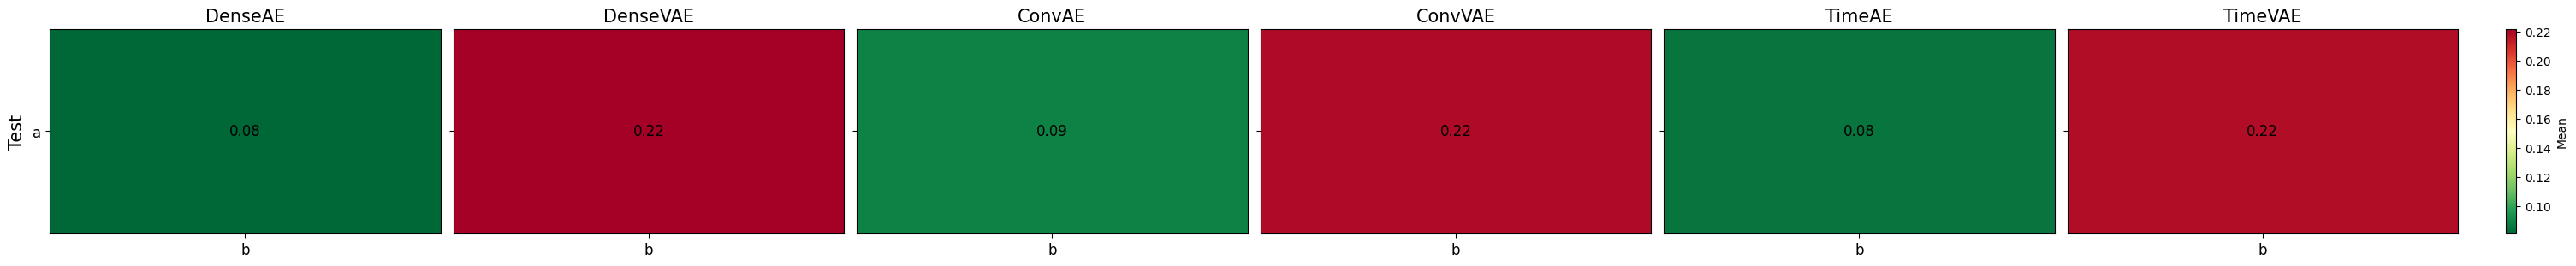

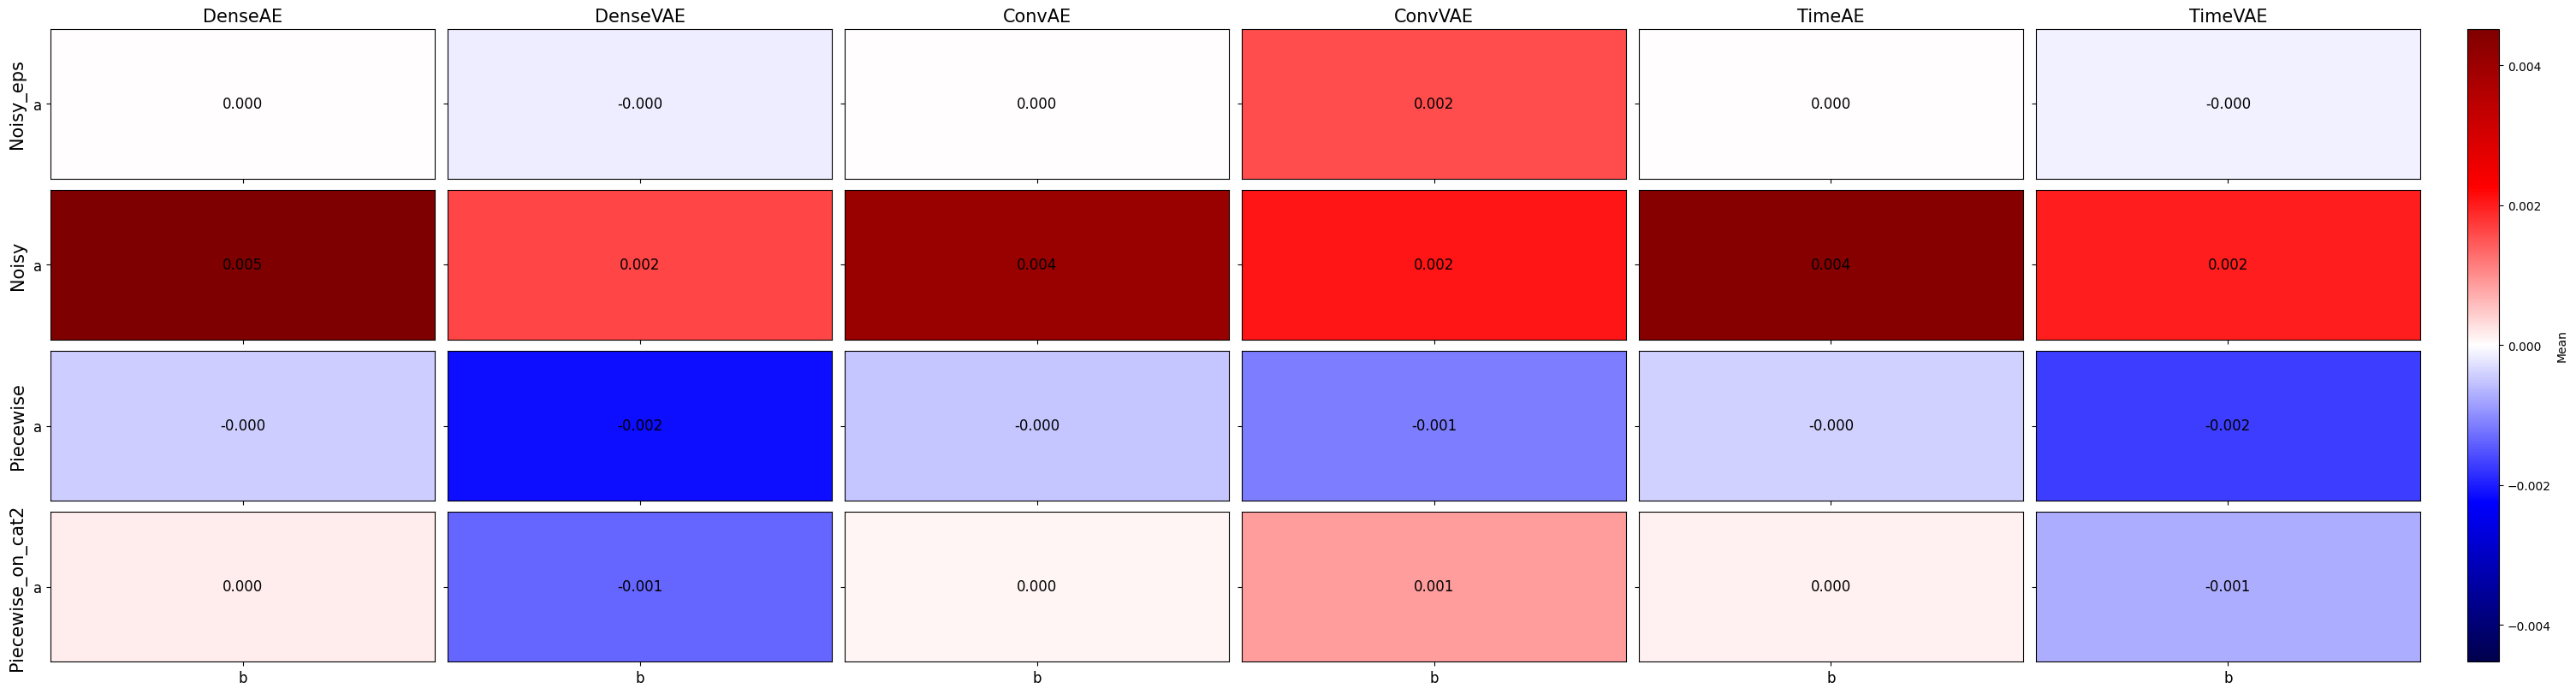

In [13]:
from abench.visu.synthesis import plot_CondGridResults

list_metrics_name = [metric.name for metric in metrics][0:1]
dict_experiments = {
                    'Test':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test'),
                    'Noisy_eps':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Noisy_eps'),
                    # 'Noisy':{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2']}
                    'Noisy':{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Noisy'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Noisy'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Noisy'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Noisy'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Noisy']},
                    'Piecewise':{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Piecewise'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Piecewise'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Piecewise'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Piecewise'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Piecewise']},
                    'Piecewise_on_cat2':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Piecewise_on_cat2')
                    }

plot_CondGridResults(dict_perf,list_component_name,list_metrics_name,dict_experiments,ctx_1=['a'],ctx_2=['b'],n_REPET=5)

{'data_Train_LOSO_set_0': ['data_Test_LOSO_set_0'], 'data_Train_LOSO_set_1': ['data_Test_LOSO_set_1'], 'data_Train_LOSO_set_2': ['data_Test_LOSO_set_2'], 'data_Train_LOSO_set_3': ['data_Test_LOSO_set_3'], 'data_Train_LOSO_set_4': ['data_Test_LOSO_set_4']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Noisy_eps'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Noisy_eps'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Noisy_eps'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Noisy_eps'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Noisy_eps']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Noisy'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Noisy'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Noisy'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Noisy'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Noisy']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Piecewise'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Piecewise'], 'data_Train_LOSO_

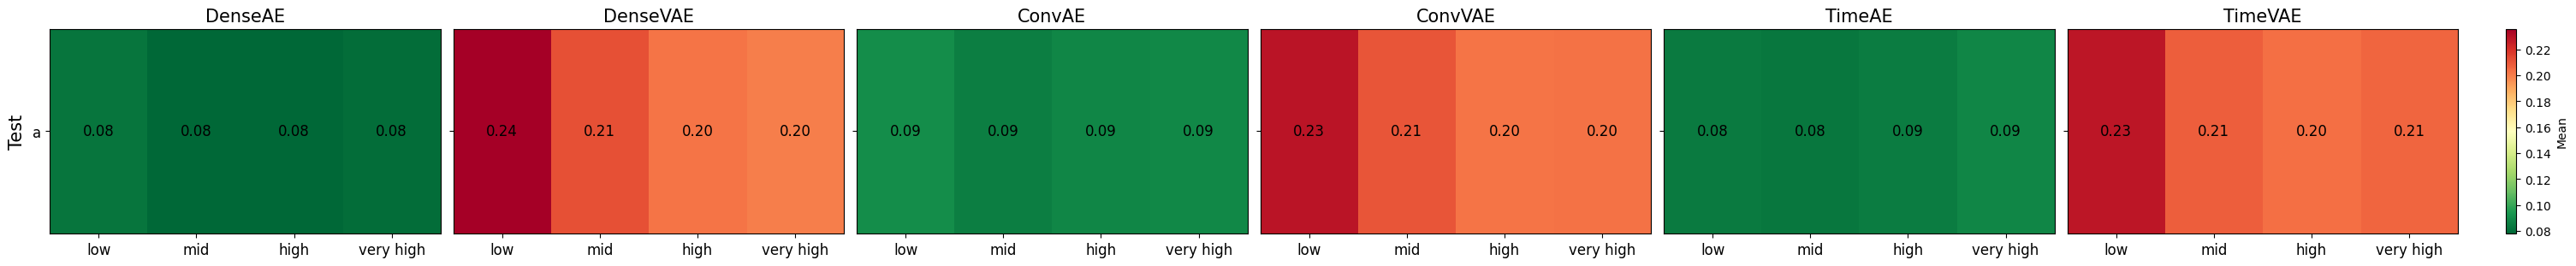

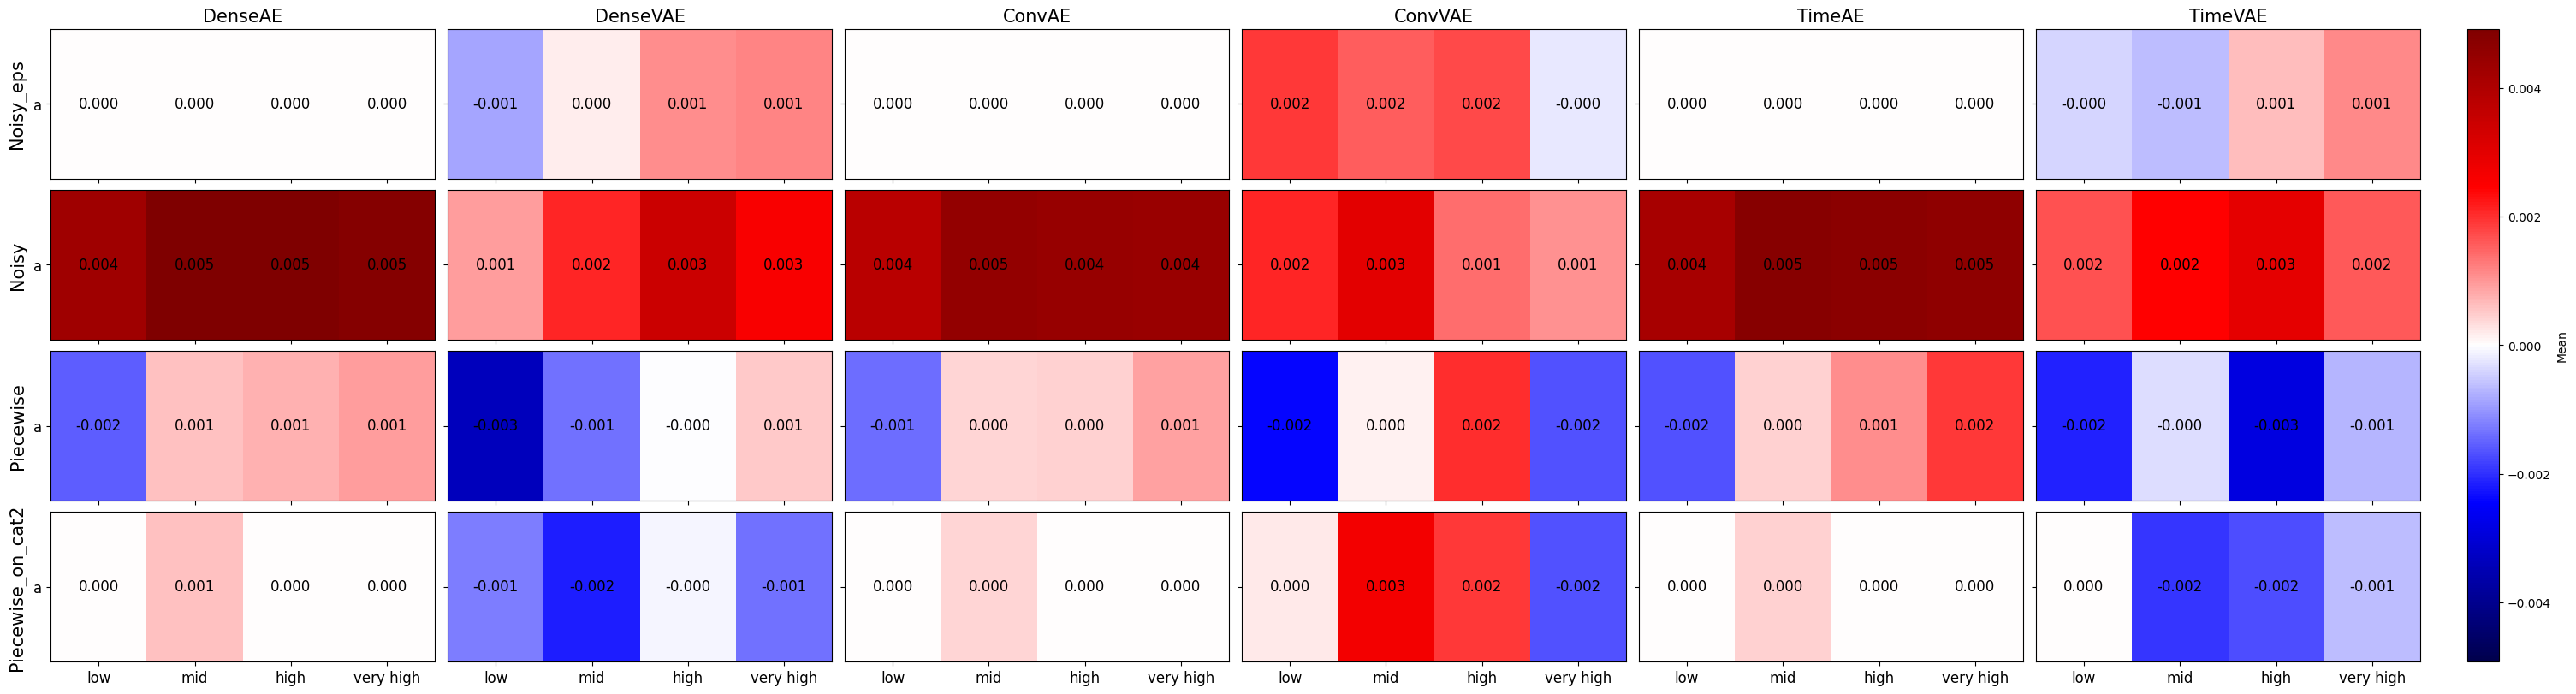

In [14]:
from abench.visu.synthesis import plot_CondGridResults

list_metrics_name = [metric.name for metric in metrics][1:2]

dict_experiments = {'Test':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test'),
                    'Noisy_eps':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Noisy_eps'),
                    'Noisy':{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Noisy'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Noisy'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Noisy'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Noisy'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Noisy']},
                    'Piecewise':{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Piecewise'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Piecewise'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Piecewise'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Piecewise'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Piecewise']},
                    'Piecewise_on_cat2':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Piecewise_on_cat2')}
# dict_experiments
plot_CondGridResults(dict_perf,list_component_name,list_metrics_name,dict_experiments,ctx_1=['a'],ctx_2=['low','mid','high','very high'],n_REPET=5)

100%|██████████| 1/1 [00:01<00:00,  1.11s/it]


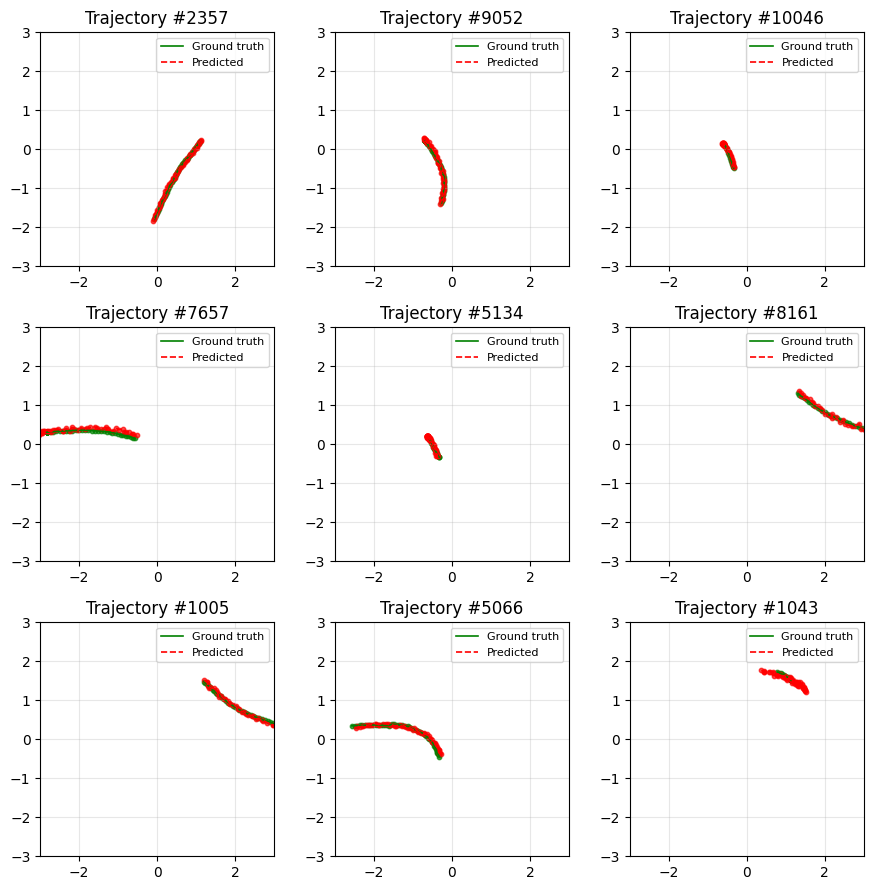

100%|██████████| 1/1 [00:00<00:00,  1.12it/s]


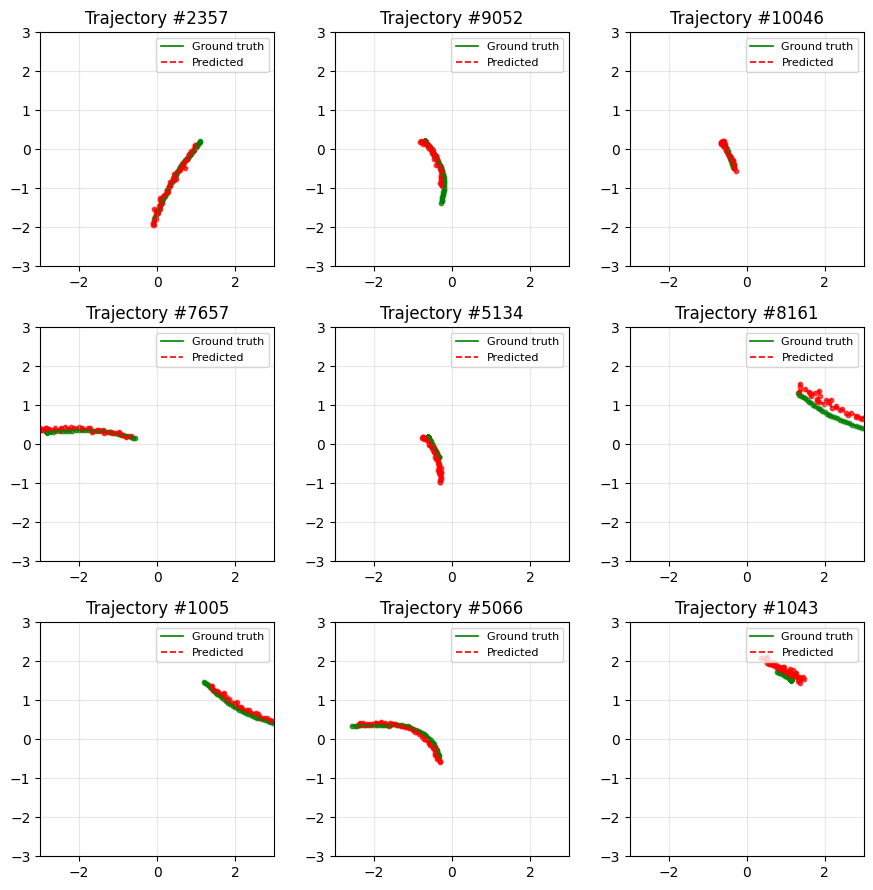

In [15]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Test_LOSO_set_1')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

In [ ]:
import abench.store.api as api
from src.metric import recon_score,ABMetricGeneric
from abench.stats.agg_test import compute_statistical_test

from abench.stats.agg_test import aggregate_test_results
def extract_list_res(res,len_cond=0):
    if(len_cond):
        list_res = []
        for j in range(len_cond):
            res_redu = [i[0][j][0] for i in res]
            list_res.append(aggregate_test_results(res_redu))
        return(list_res)
    else:
        res_redu = [i[0][0] for i in res]
        return(aggregate_test_results(res_redu))


storing = 'Results'
component_name = 'DenseAE'
Exp_plan_ref = api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test')
for test_filters in ['Noisy_eps','Noisy','Piecewise']:
    Exp_plan_cmp = api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters=test_filters)
    metric = ABMetricGeneric(metric=recon_score,name="recon_score", mask=None, dim_mask=None, list_ctx_constraint=None,reduce=False)
    res = compute_statistical_test(storing,'DenseAE','DenseAE',Exp_plan_ref,Exp_plan_cmp,metric)
    print(test_filters, extract_list_res(res,len_cond=0))

ModuleNotFoundError: No module named 'abench.stats'

In [ ]:
Exp_plan_ref = api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test')

for test_filters in ['Piecewise','Piecewise_on_cat2']:
    Exp_plan_cmp = api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters=test_filters)
    metric = ABMetricGeneric(recon_score, name="RMSE_grid",dict_sets_config=dict_sets_configs_grid1,reduce=False)
    res = compute_statistical_test(storing,'DenseAE','DenseAE',Exp_plan_ref,Exp_plan_cmp,metric)
    for i in extract_list_res(res,len_cond=4):
        print(i,i)
    print()

100%|██████████| 5/5 [00:00<00:00,  6.20it/s]


AggregatedTestResult(statistic=-15.370194932451843, pvalue=2.5938756823715565e-53, method='mean_z', extra={'per_fold_stats': [-8.303474230752485, -9.32002098945182, -8.998463325039978]}) AggregatedTestResult(statistic=-15.370194932451843, pvalue=2.5938756823715565e-53, method='mean_z', extra={'per_fold_stats': [-8.303474230752485, -9.32002098945182, -8.998463325039978]})
AggregatedTestResult(statistic=-21.701767188580988, pvalue=1.974278337430605e-104, method='mean_z', extra={'per_fold_stats': [-12.136304520804465, -12.254854715800182, -13.197404148048816]}) AggregatedTestResult(statistic=-21.701767188580988, pvalue=1.974278337430605e-104, method='mean_z', extra={'per_fold_stats': [-12.136304520804465, -12.254854715800182, -13.197404148048816]})
AggregatedTestResult(statistic=-18.86677756175449, pvalue=2.139539798593326e-79, method='mean_z', extra={'per_fold_stats': [-10.097538137807163, -10.953272564530073, -11.627406609722003]}) AggregatedTestResult(statistic=-18.86677756175449, pval

100%|██████████| 5/5 [00:00<00:00,  6.16it/s]


AggregatedTestResult(statistic=0.0, pvalue=1.0, method='mean_z', extra={'per_fold_stats': [0.0, 0.0, 0.0]}) AggregatedTestResult(statistic=0.0, pvalue=1.0, method='mean_z', extra={'per_fold_stats': [0.0, 0.0, 0.0]})
AggregatedTestResult(statistic=-21.701767188580988, pvalue=1.974278337430605e-104, method='mean_z', extra={'per_fold_stats': [-12.136304520804465, -12.254854715800182, -13.197404148048816]}) AggregatedTestResult(statistic=-21.701767188580988, pvalue=1.974278337430605e-104, method='mean_z', extra={'per_fold_stats': [-12.136304520804465, -12.254854715800182, -13.197404148048816]})
AggregatedTestResult(statistic=0.0, pvalue=1.0, method='mean_z', extra={'per_fold_stats': [0.0, 0.0, 0.0]}) AggregatedTestResult(statistic=0.0, pvalue=1.0, method='mean_z', extra={'per_fold_stats': [0.0, 0.0, 0.0]})
AggregatedTestResult(statistic=0.0, pvalue=1.0, method='mean_z', extra={'per_fold_stats': [0.0, 0.0, 0.0]}) AggregatedTestResult(statistic=0.0, pvalue=1.0, method='mean_z', extra={'per_f

# Rolling window 5s

{'data_Train_LOSO_set_0': ['data_Test_LOSO_set_0'], 'data_Train_LOSO_set_1': ['data_Test_LOSO_set_1'], 'data_Train_LOSO_set_2': ['data_Test_LOSO_set_2'], 'data_Train_LOSO_set_3': ['data_Test_LOSO_set_3'], 'data_Train_LOSO_set_4': ['data_Test_LOSO_set_4']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Random_pos_offset_low'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Random_pos_offset_low'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Random_pos_offset_low'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Random_pos_offset_low'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Random_pos_offset_low']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Random_pos_offset_median'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Random_pos_offset_median'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Random_pos_offset_median'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Random_pos_offset_median'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Random_pos_offs

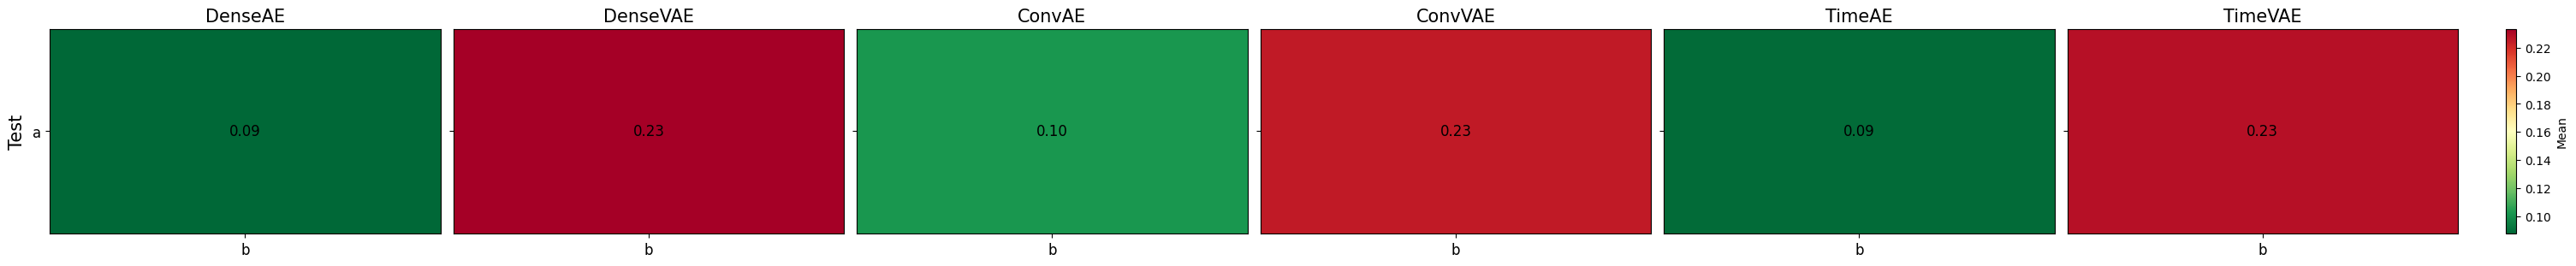

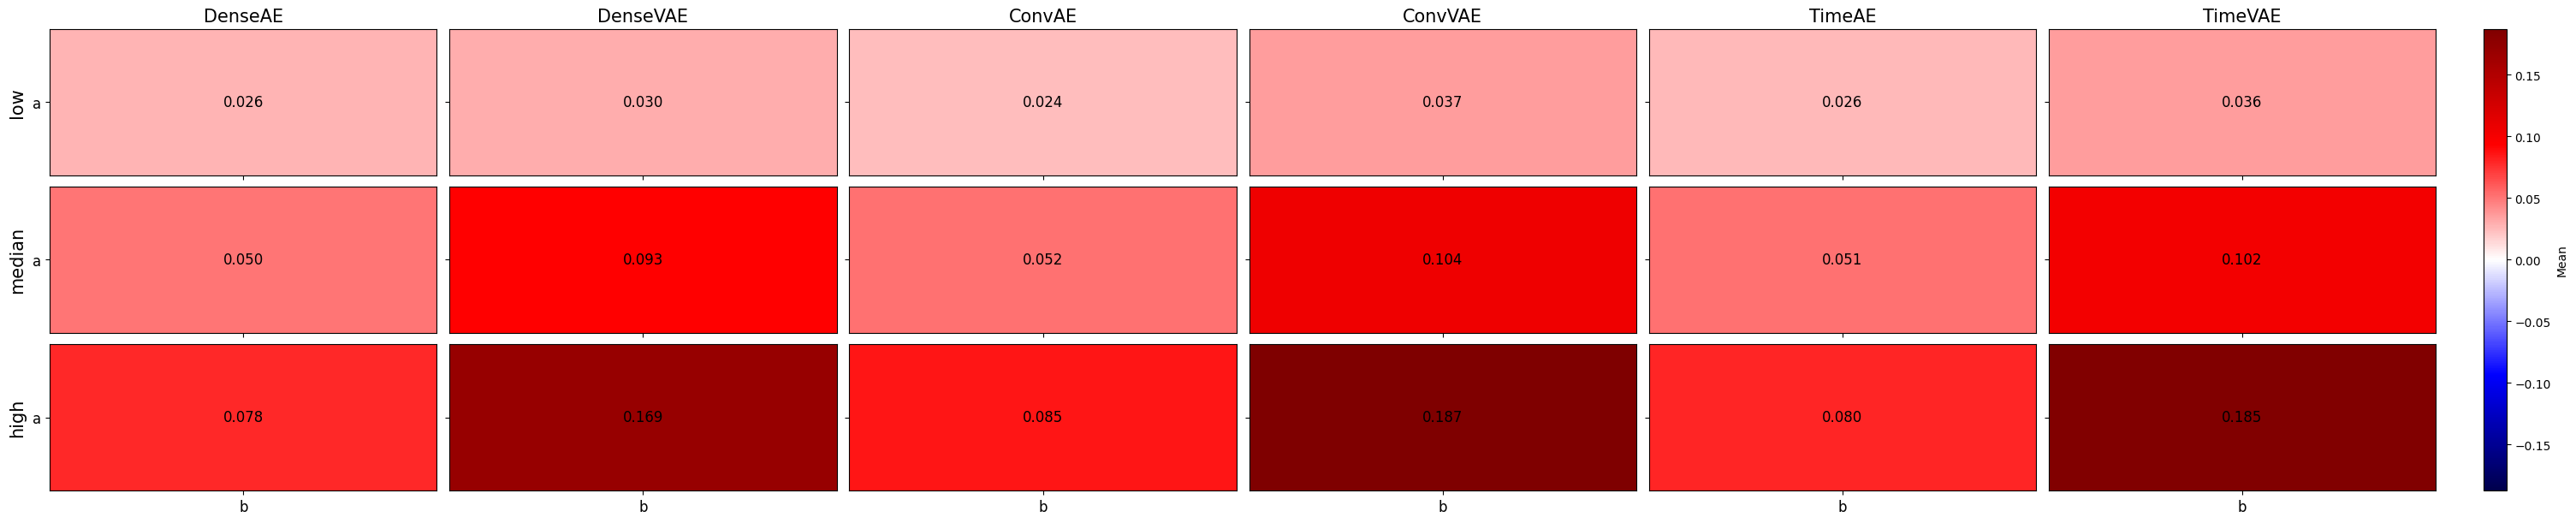

In [9]:
from abench.visu.synthesis import plot_CondGridResults

list_metrics_name = [metric.name for metric in metrics][0:1]
dict_experiments = {
                    'Test':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test'),
                    'low':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_low'),
                    'median':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_median'),
                    'high':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_high')
                    }

plot_CondGridResults(dict_perf,list_component_name,list_metrics_name,dict_experiments,ctx_1=['a'],ctx_2=['b'],n_REPET=5)

{'data_Train_LOSO_set_0': ['data_Test_LOSO_set_0'], 'data_Train_LOSO_set_1': ['data_Test_LOSO_set_1'], 'data_Train_LOSO_set_2': ['data_Test_LOSO_set_2'], 'data_Train_LOSO_set_3': ['data_Test_LOSO_set_3'], 'data_Train_LOSO_set_4': ['data_Test_LOSO_set_4']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Random_pos_offset_low'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Random_pos_offset_low'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Random_pos_offset_low'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Random_pos_offset_low'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Random_pos_offset_low']}
{'data_Train_LOSO_set_0': ['data_Valid_LOSO_set_0_Random_pos_offset_median'], 'data_Train_LOSO_set_1': ['data_Valid_LOSO_set_1_Random_pos_offset_median'], 'data_Train_LOSO_set_2': ['data_Valid_LOSO_set_2_Random_pos_offset_median'], 'data_Train_LOSO_set_3': ['data_Valid_LOSO_set_3_Random_pos_offset_median'], 'data_Train_LOSO_set_4': ['data_Valid_LOSO_set_4_Random_pos_offs

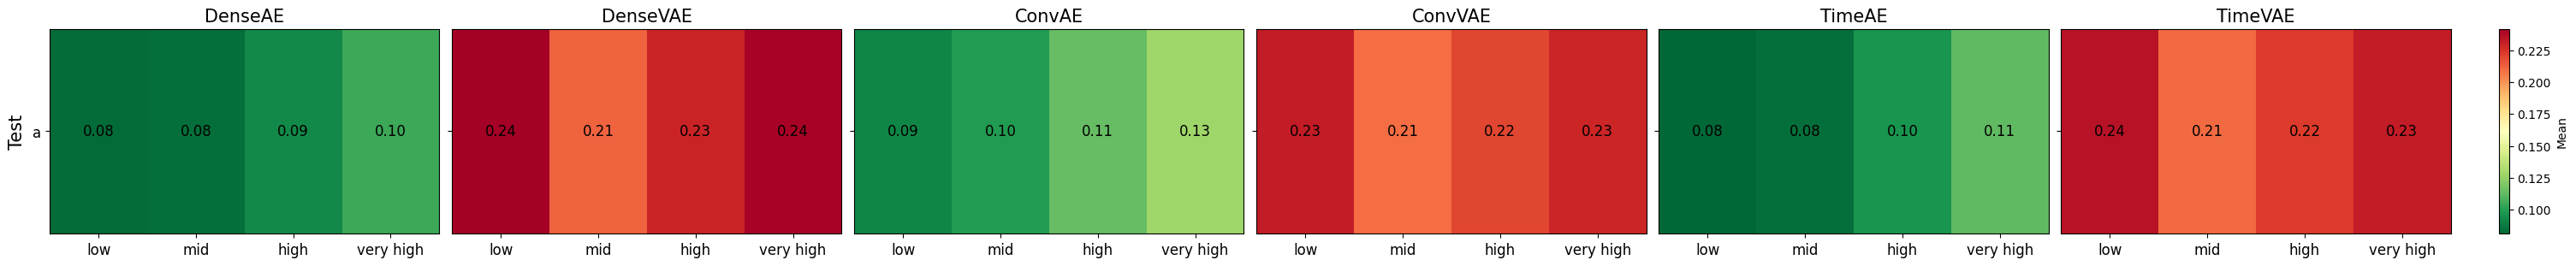

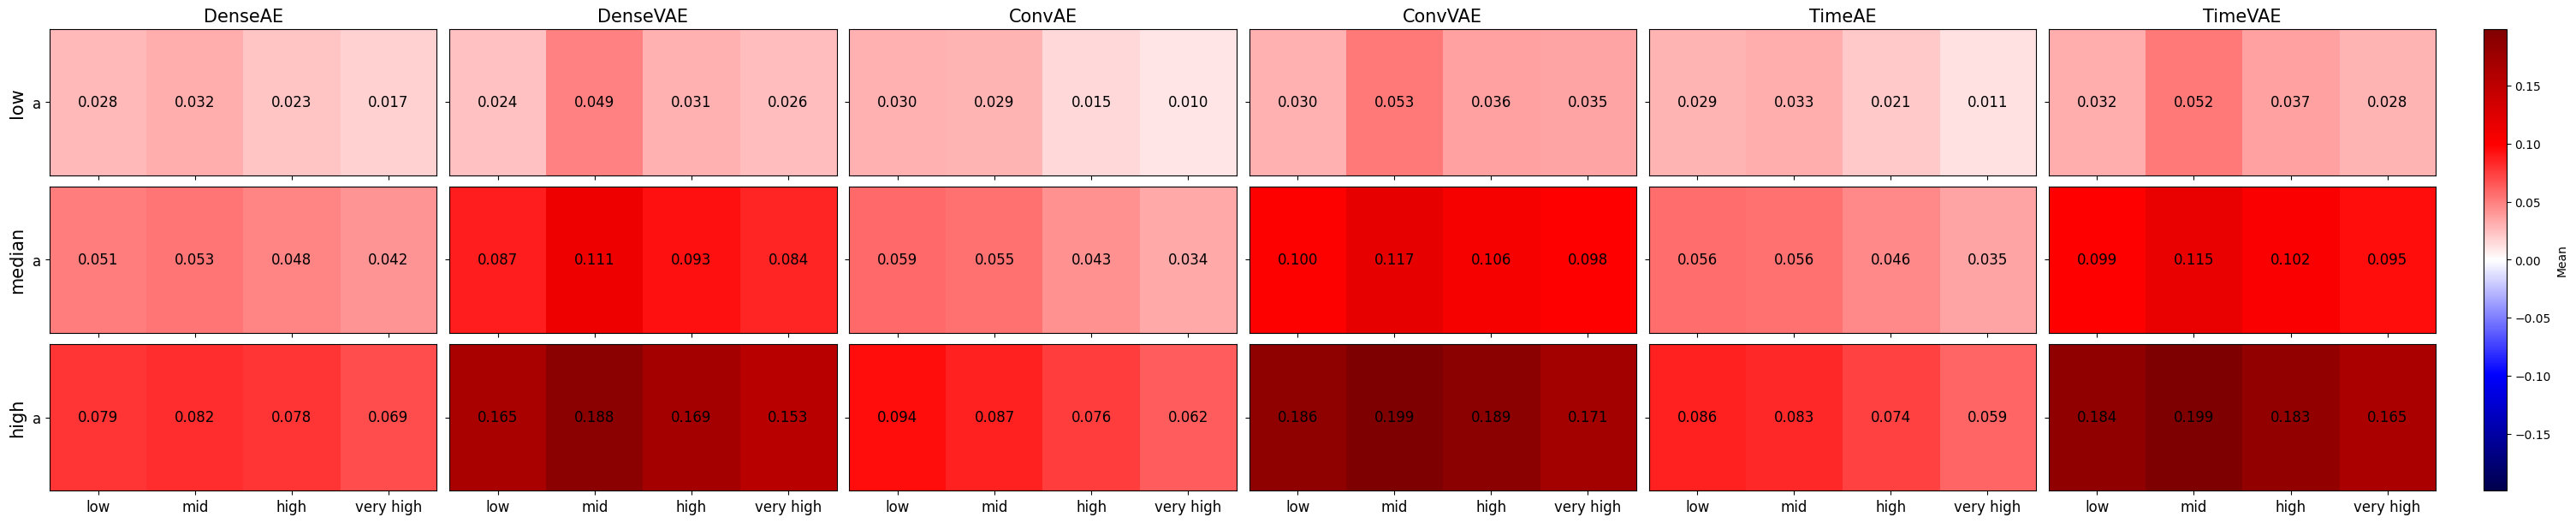

In [11]:
from abench.visu.synthesis import plot_CondGridResults

list_metrics_name = [metric.name for metric in metrics][1:2]

dict_experiments = {
                    'Test':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test'),
                    'low':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_low'),
                    'median':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_median'),
                    'high':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_high')
                    }
# dict_experiments
plot_CondGridResults(dict_perf,list_component_name,list_metrics_name,dict_experiments,ctx_1=['a'],ctx_2=['low','mid','high','very high'],n_REPET=5)

100%|██████████| 5/5 [00:00<00:00,  8.46it/s]


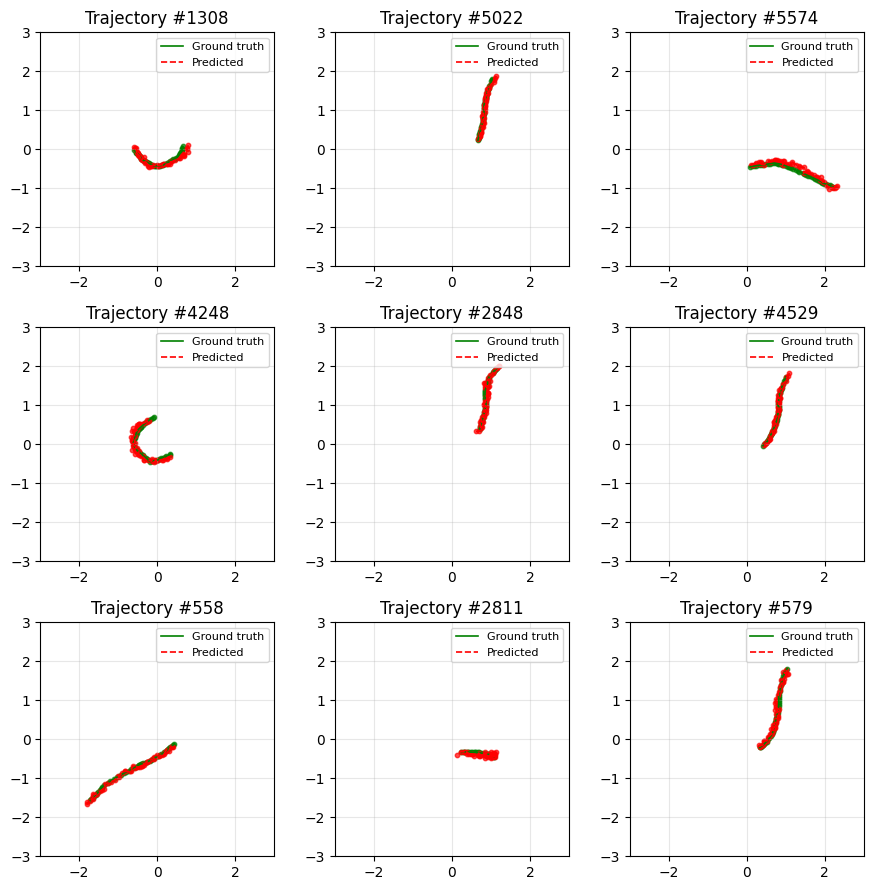

100%|██████████| 5/5 [00:00<00:00,  8.28it/s]


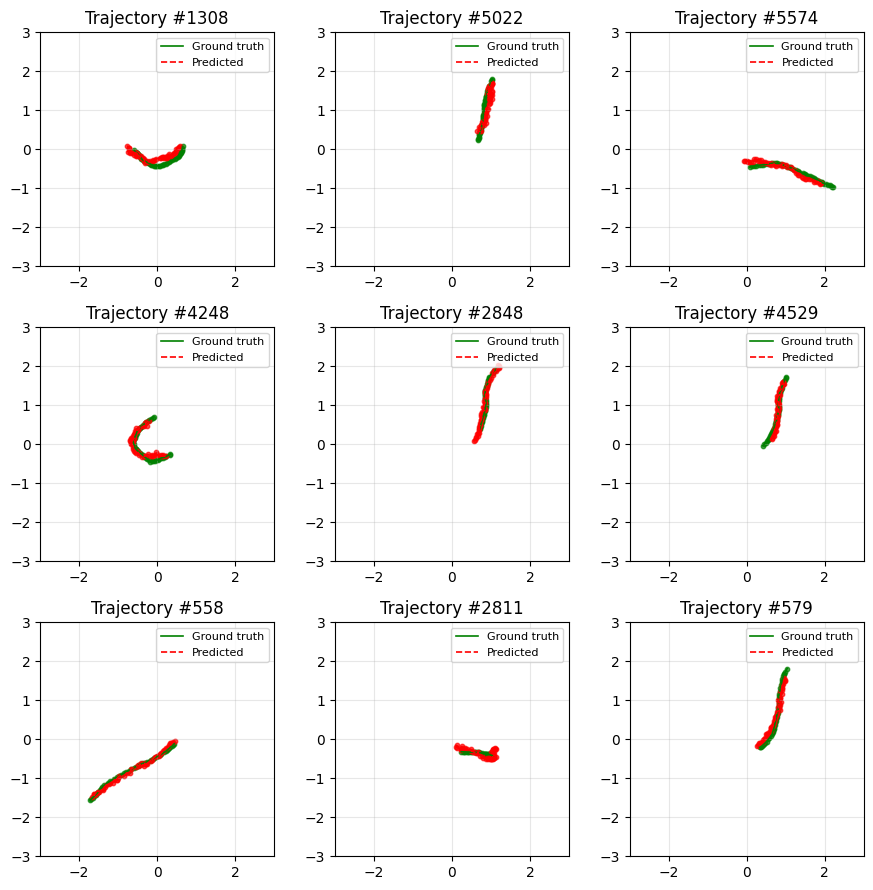

In [13]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Test_LOSO_set_1')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

100%|██████████| 5/5 [00:00<00:00,  7.76it/s]


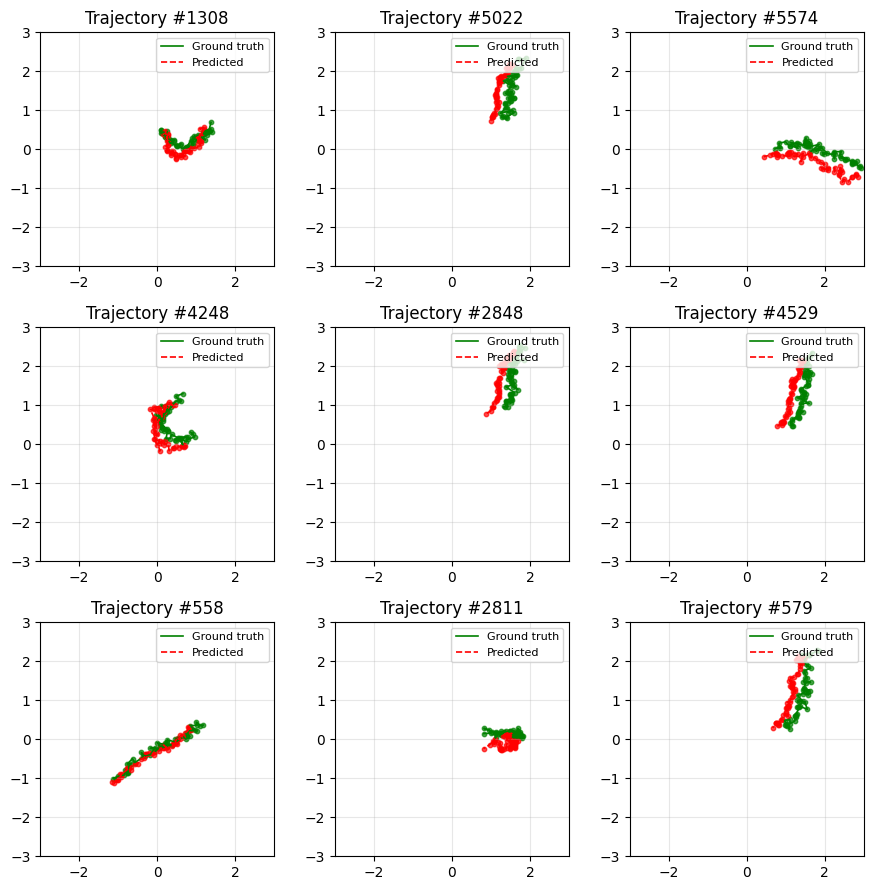

100%|██████████| 5/5 [00:00<00:00,  6.88it/s]


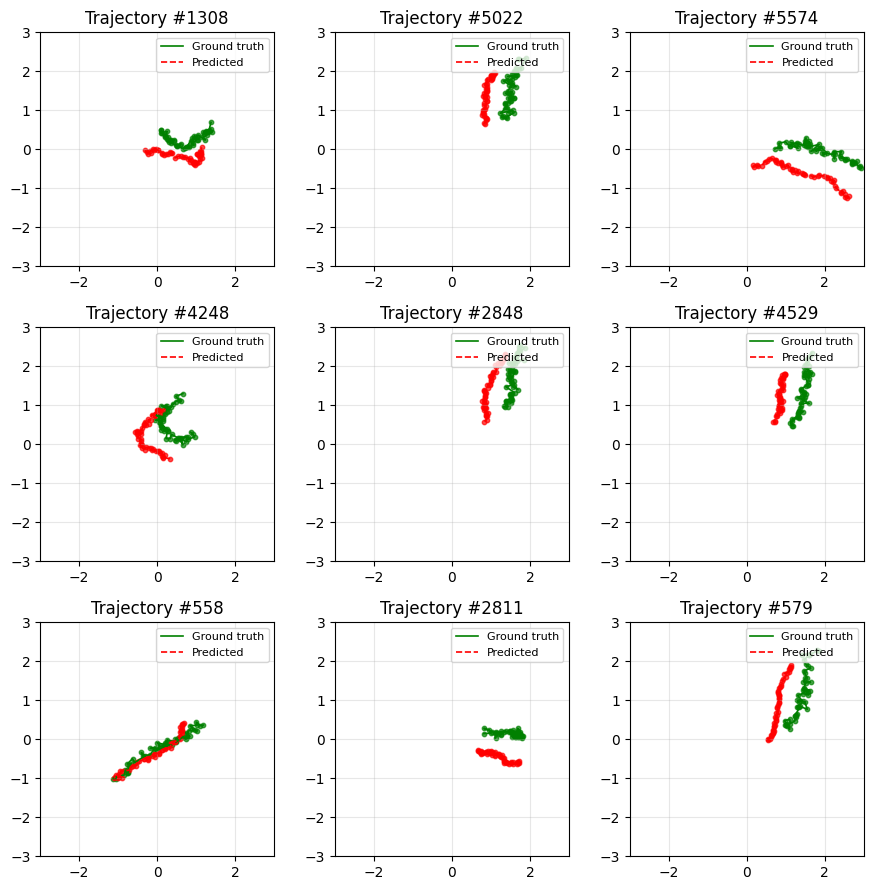

In [14]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Valid_LOSO_set_1_Random_pos_offset_high')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

100%|██████████| 5/5 [00:00<00:00,  7.41it/s]


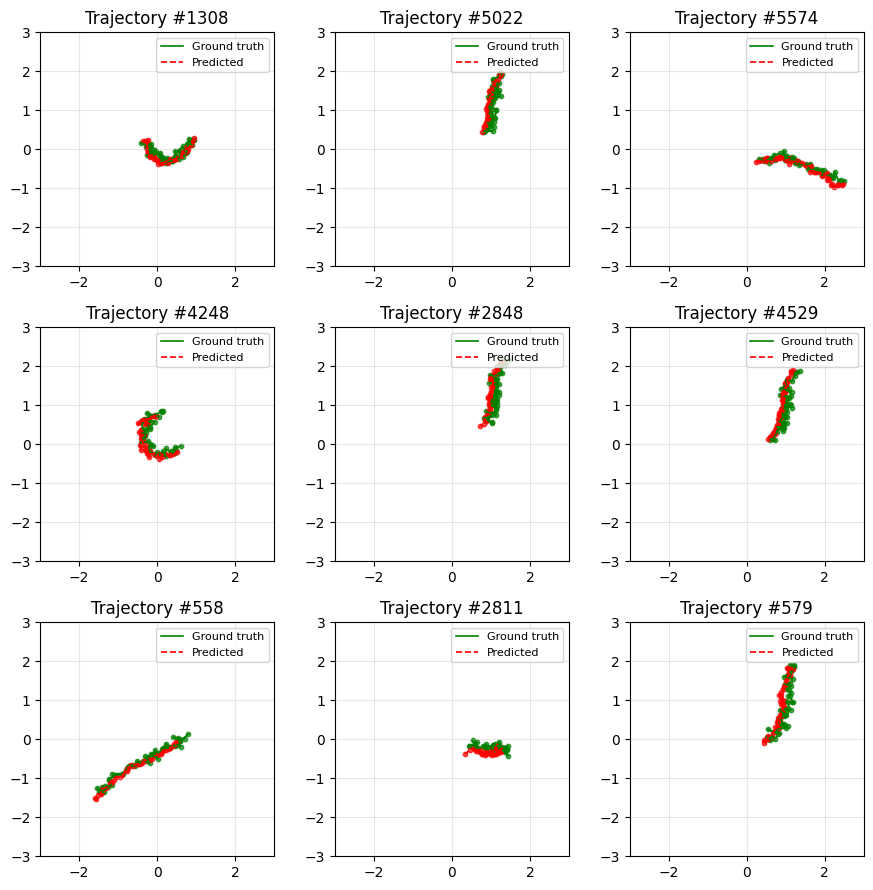

100%|██████████| 5/5 [00:00<00:00,  8.90it/s]


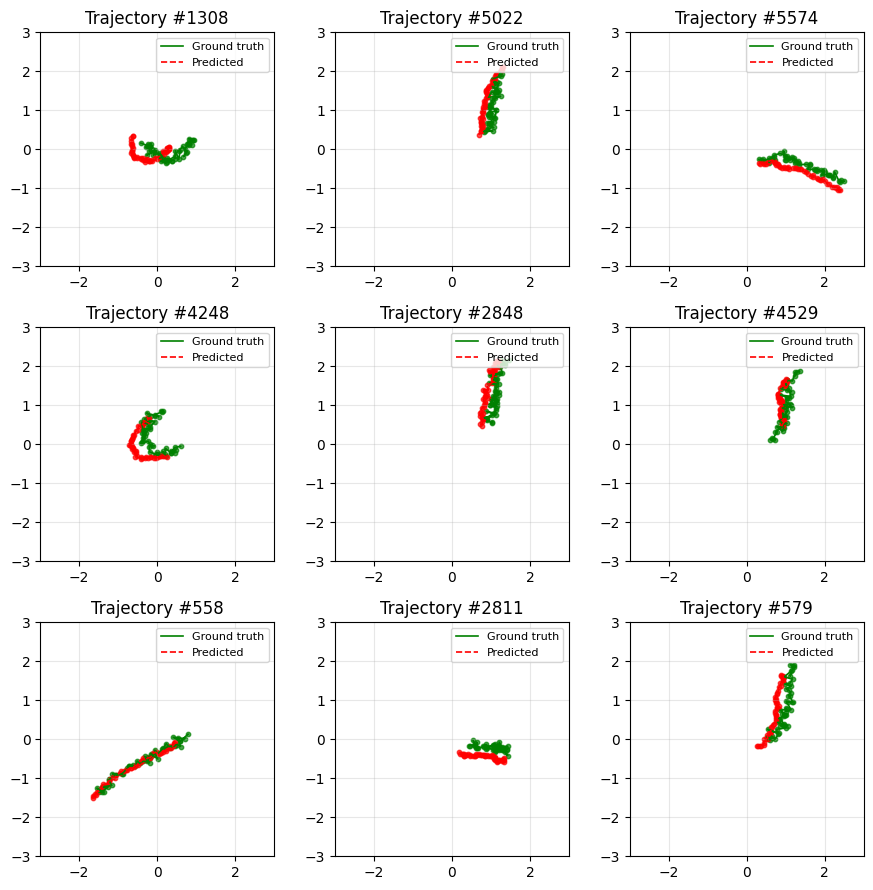

In [20]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Valid_LOSO_set_1_Random_pos_offset_low')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

100%|██████████| 5/5 [00:00<00:00,  7.34it/s]


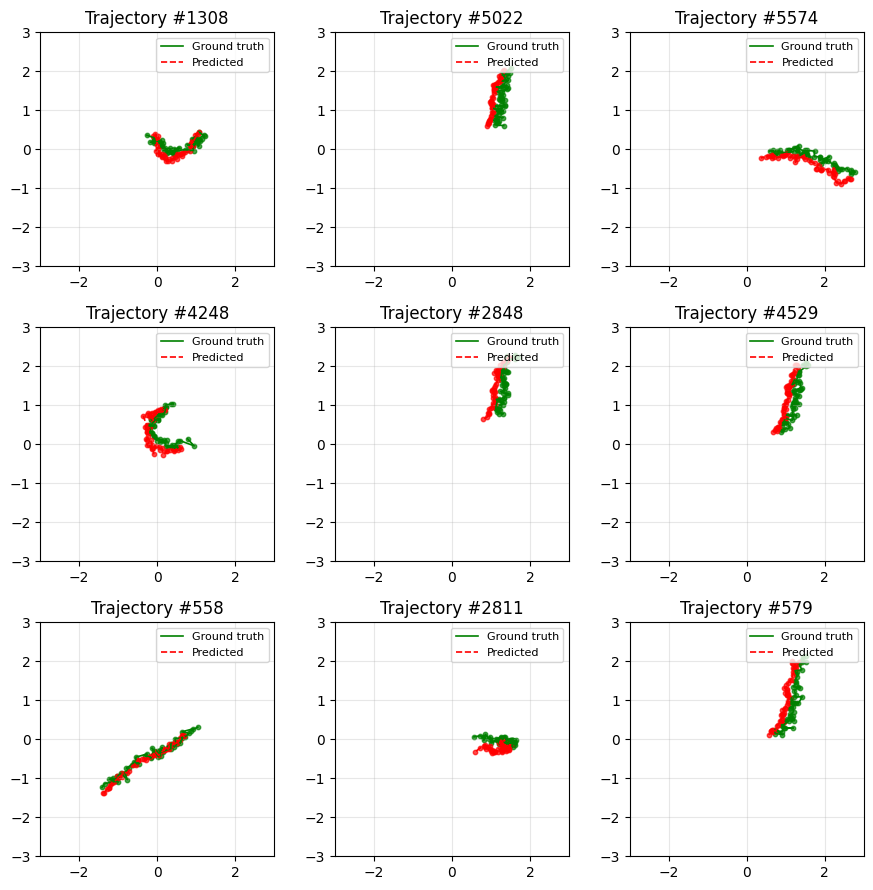

100%|██████████| 5/5 [00:00<00:00,  8.96it/s]


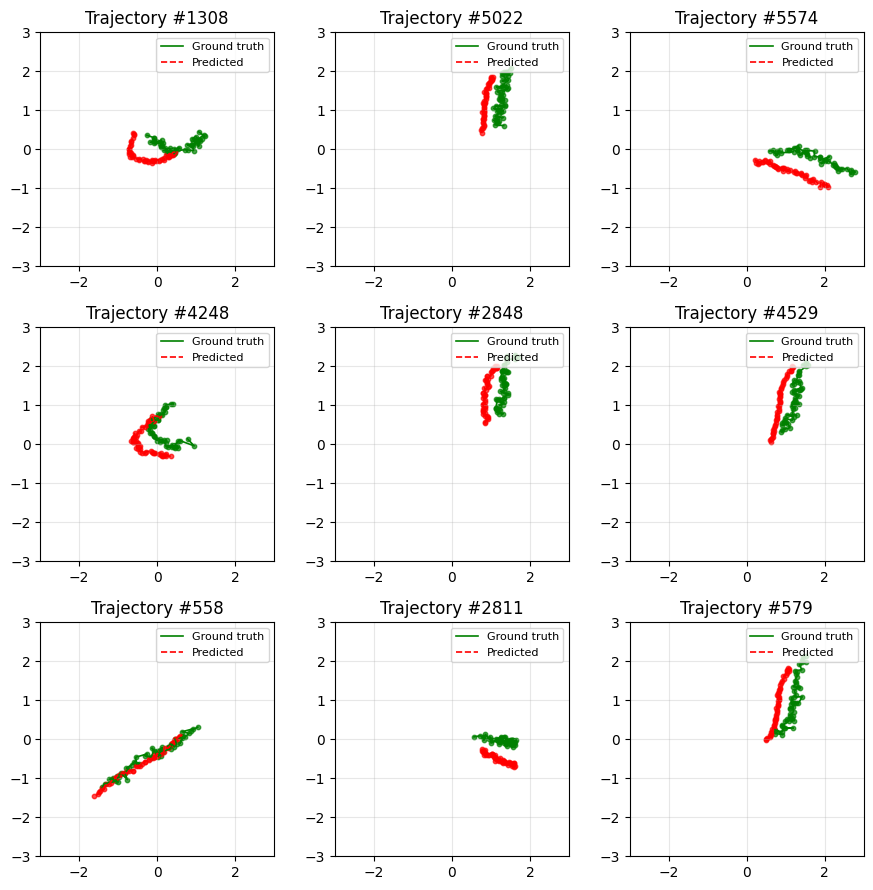

In [21]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Valid_LOSO_set_1_Random_pos_offset_median')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

# Rolling window 1s

In [ ]:
# Update full data experiment 
import yaml
config_benchmark_path = "config/config_benchmark.yaml"
with open(config_benchmark_path) as f:
    config_benchmark = yaml.safe_load(f)

storing = 'Results/'
from src.data_loader import get_DataExperiment
# config_benchmark['validation_config']['Noisy_eps'] = {'constraint_selection': [['dataset',['dataset1_noisy_eps']]], 'constraint_rejection': []}
DataExperiment = get_DataExperiment(config_benchmark,with_test=True)
from abench.store.api import store_ABDataExperiment
store_ABDataExperiment(storing,DataExperiment)

In [9]:
from src.metric import base_rmse,ABMetricGeneric
AB_RMSE = ABMetricGeneric(metric=base_rmse,name="rmse", mask=None, dim_mask=None, list_ctx_constraint=None,reduce=True)
list_metrics = [AB_RMSE]

storing = 'Results'
#['Id'0, 'timestamp'1, 'positionX'2, 'positionY'3, 'positionZ'4, 'sizeX'5,'sizeY+', 'sizeZ7', 'VelX'8, 'VelY'9, 'VelZ'10, 'Vel'11, 'Class'12, 'rot_x'13,'rot_y'14, 'edge'15, 'ts'16, 'departure'17, 'destination'18, 'dataset'19, 'set'20,'filename'21, 'seqId'22, 'length'23, 'cat_length'24, 'cat_edge'25],
dict_sets_configs_grid1={'context_mask':[0],'context_dim_mask':1,'context_variable_ids':[[24]]}

metrics = [ABMetricGeneric(base_rmse, name="RMSE",reduce=True),
           ABMetricGeneric(base_rmse, name="RMSE_grid",dict_sets_config=dict_sets_configs_grid1,reduce=True)]

from abench.benchmark.benchmark import compute_metrics_on_dataloader,perf_agg_compute

list_component_name = ['DenseAE','DenseVAE','ConvAE','ConvVAE','TimeAE','TimeVAE']

ABDataExperiment = api.get_ABDataExperiment(storing,name='cv_experiment')
Exp_plan = ABDataExperiment.get_experiment_plan()
print('Experiments_plan',Exp_plan)

for Train_set,Test_set_list in Exp_plan.items():
    for set_name in Test_set_list:
        compute_metrics_on_dataloader(storing=storing,trainset_name=Train_set,list_component_name=list_component_name,list_metrics=metrics,set_name=set_name)
    
dict_perf = perf_agg_compute(storing,experiment_plan=Exp_plan,list_component_name=list_component_name,list_metrics=metrics,agg_name=set_name)

Experiments_plan {'data_Train_LOSO_r2_set_0': ['data_Test_LOSO_r2_set_0', 'data_Valid_LOSO_r2_set_0_Random_pos_offset_low', 'data_Valid_LOSO_r2_set_0_Random_pos_offset_median', 'data_Valid_LOSO_r2_set_0_Random_pos_offset_high'], 'data_Train_LOSO_r2_set_1': ['data_Test_LOSO_r2_set_1', 'data_Valid_LOSO_r2_set_1_Random_pos_offset_low', 'data_Valid_LOSO_r2_set_1_Random_pos_offset_median', 'data_Valid_LOSO_r2_set_1_Random_pos_offset_high'], 'data_Train_LOSO_r2_set_2': ['data_Test_LOSO_r2_set_2', 'data_Valid_LOSO_r2_set_2_Random_pos_offset_low', 'data_Valid_LOSO_r2_set_2_Random_pos_offset_median', 'data_Valid_LOSO_r2_set_2_Random_pos_offset_high'], 'data_Train_LOSO_r2_set_3': ['data_Test_LOSO_r2_set_3', 'data_Valid_LOSO_r2_set_3_Random_pos_offset_low', 'data_Valid_LOSO_r2_set_3_Random_pos_offset_median', 'data_Valid_LOSO_r2_set_3_Random_pos_offset_high'], 'data_Train_LOSO_r2_set_4': ['data_Test_LOSO_r2_set_4', 'data_Valid_LOSO_r2_set_4_Random_pos_offset_low', 'data_Valid_LOSO_r2_set_4_Random

100%|██████████| 5/5 [00:00<00:00,  9.91it/s]


DenseAE RMSE Train nan ± nan | TEST 0.119 ± 0.033
DenseAE RMSE_grid Train nan ± nan | TEST [] ± []
DenseVAE RMSE Train nan ± nan | TEST 0.317 ± 0.082
DenseVAE RMSE_grid Train nan ± nan | TEST [] ± []
ConvAE RMSE Train nan ± nan | TEST 0.119 ± 0.038
ConvAE RMSE_grid Train nan ± nan | TEST [] ± []
ConvVAE RMSE Train nan ± nan | TEST 0.324 ± 0.088
ConvVAE RMSE_grid Train nan ± nan | TEST [] ± []
TimeAE RMSE Train nan ± nan | TEST 0.121 ± 0.046
TimeAE RMSE_grid Train nan ± nan | TEST [] ± []
TimeVAE RMSE Train nan ± nan | TEST 0.325 ± 0.088
TimeVAE RMSE_grid Train nan ± nan | TEST [] ± []


{'data_Train_LOSO_r2_set_0': ['data_Test_LOSO_r2_set_0'], 'data_Train_LOSO_r2_set_1': ['data_Test_LOSO_r2_set_1'], 'data_Train_LOSO_r2_set_2': ['data_Test_LOSO_r2_set_2'], 'data_Train_LOSO_r2_set_3': ['data_Test_LOSO_r2_set_3'], 'data_Train_LOSO_r2_set_4': ['data_Test_LOSO_r2_set_4']}
{'data_Train_LOSO_r2_set_0': ['data_Valid_LOSO_r2_set_0_Random_pos_offset_low'], 'data_Train_LOSO_r2_set_1': ['data_Valid_LOSO_r2_set_1_Random_pos_offset_low'], 'data_Train_LOSO_r2_set_2': ['data_Valid_LOSO_r2_set_2_Random_pos_offset_low'], 'data_Train_LOSO_r2_set_3': ['data_Valid_LOSO_r2_set_3_Random_pos_offset_low'], 'data_Train_LOSO_r2_set_4': ['data_Valid_LOSO_r2_set_4_Random_pos_offset_low']}
{'data_Train_LOSO_r2_set_0': ['data_Valid_LOSO_r2_set_0_Random_pos_offset_median'], 'data_Train_LOSO_r2_set_1': ['data_Valid_LOSO_r2_set_1_Random_pos_offset_median'], 'data_Train_LOSO_r2_set_2': ['data_Valid_LOSO_r2_set_2_Random_pos_offset_median'], 'data_Train_LOSO_r2_set_3': ['data_Valid_LOSO_r2_set_3_Random_p

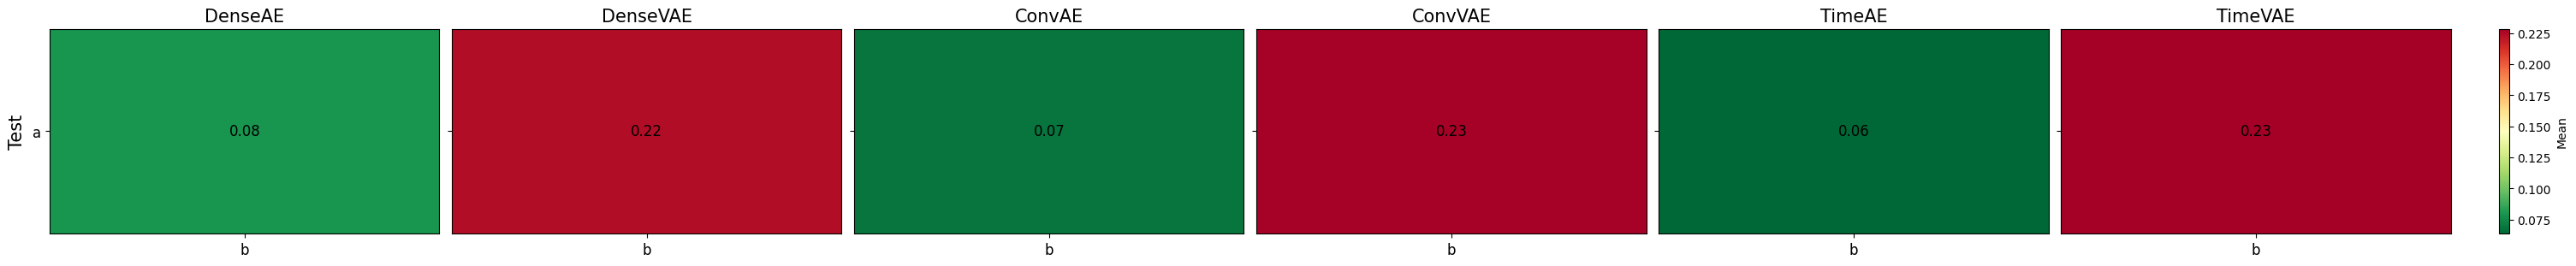

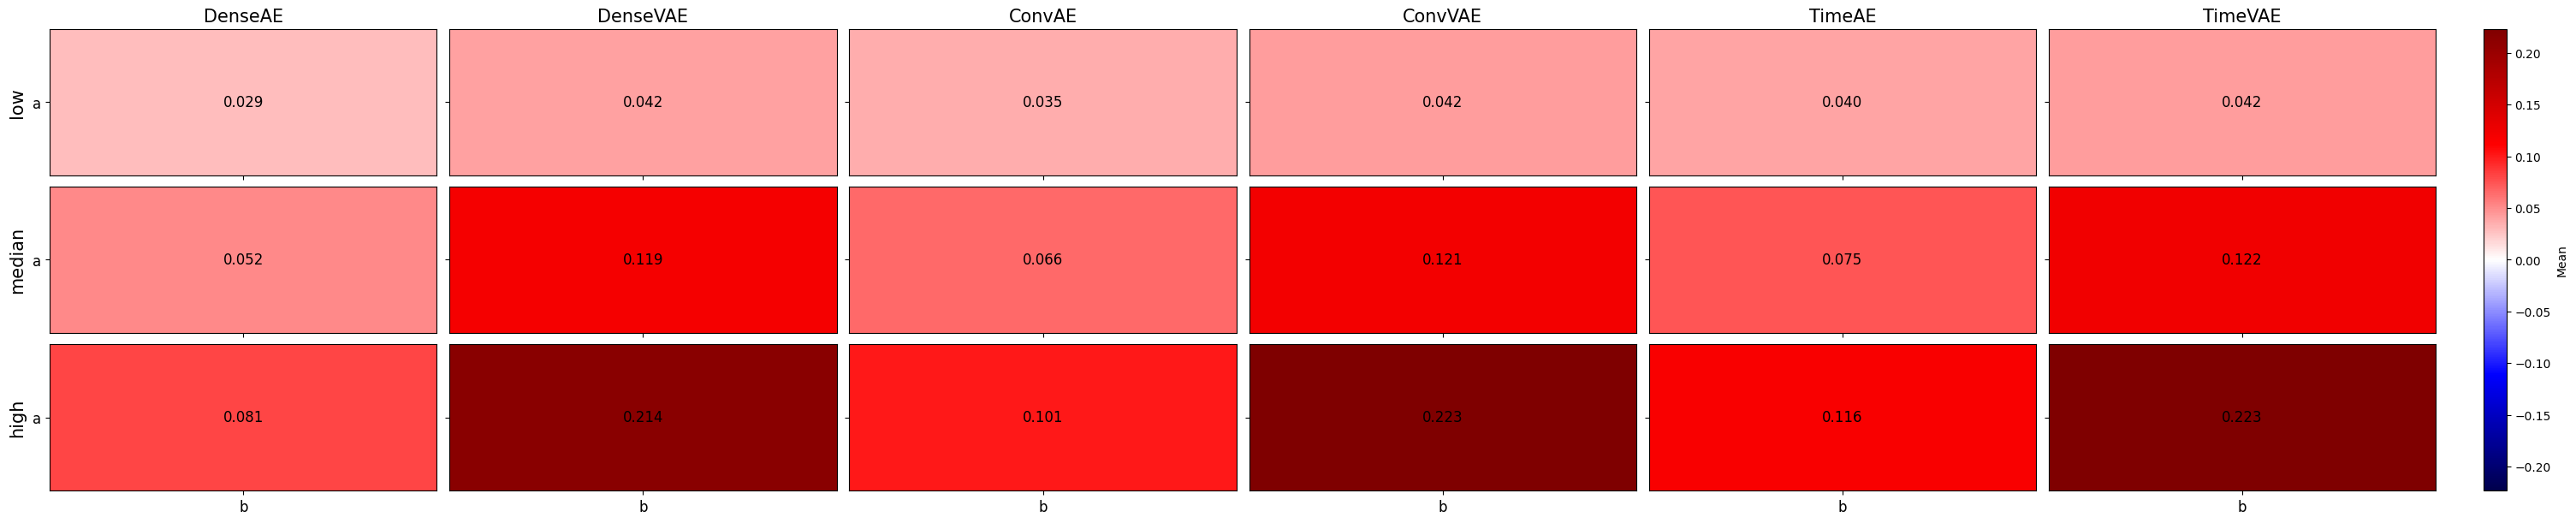

In [5]:
from abench.visu.synthesis import plot_CondGridResults

list_metrics_name = [metric.name for metric in metrics][0:1]
dict_experiments = {
                    'Test':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test'),
                    'low':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_low'),
                    'median':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_median'),
                    'high':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_high')
                    }

plot_CondGridResults(dict_perf,list_component_name,list_metrics_name,dict_experiments,ctx_1=['a'],ctx_2=['b'],n_REPET=5)

In [8]:
from abench.visu.synthesis import plot_CondGridResults

list_metrics_name = [metric.name for metric in metrics][1:2]

dict_experiments = {
                    'Test':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Test'),
                    'low':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_low'),
                    'median':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_median'),
                    'high':api.filter_experiment_plan(Exp_plan,train_filters=None,test_filters='Random_pos_offset_high')
                    }
# dict_experiments
plot_CondGridResults(dict_perf,list_component_name,list_metrics_name,dict_experiments,ctx_1=['a'],ctx_2=['low','mid','high','very high'],n_REPET=1)

{'data_Train_LOSO_r2_set_0': ['data_Test_LOSO_r2_set_0'], 'data_Train_LOSO_r2_set_1': ['data_Test_LOSO_r2_set_1'], 'data_Train_LOSO_r2_set_2': ['data_Test_LOSO_r2_set_2'], 'data_Train_LOSO_r2_set_3': ['data_Test_LOSO_r2_set_3'], 'data_Train_LOSO_r2_set_4': ['data_Test_LOSO_r2_set_4']}


ValueError: cannot reshape array of size 0 into shape (1,1,4)

100%|██████████| 5/5 [00:00<00:00,  8.46it/s]


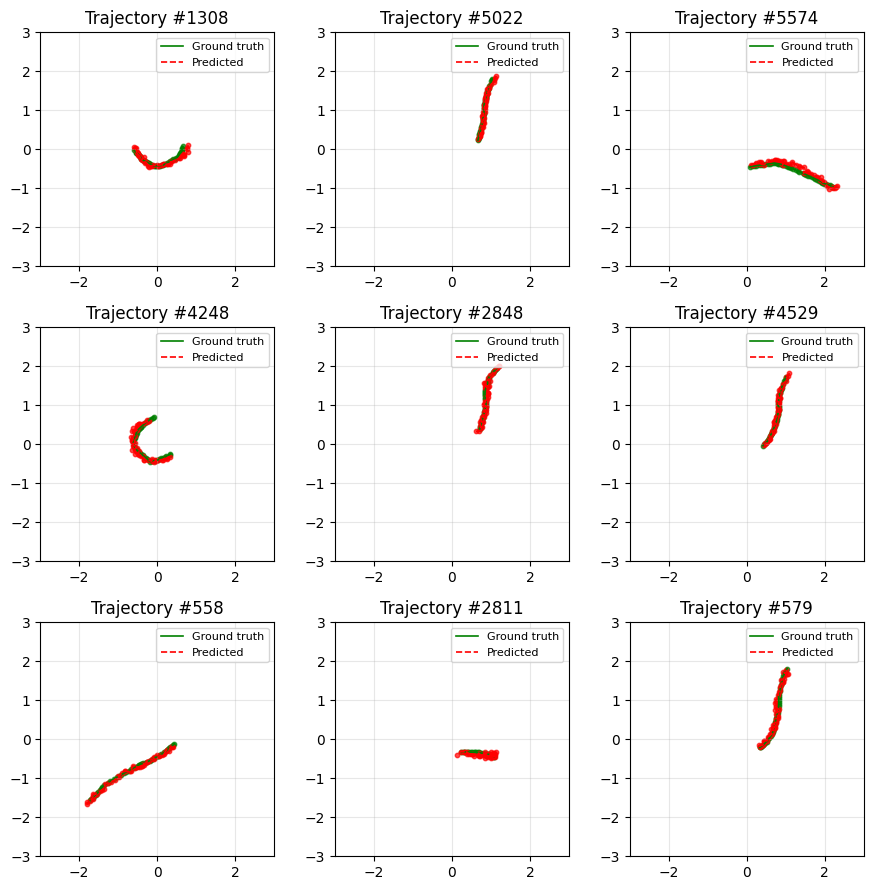

100%|██████████| 5/5 [00:00<00:00,  8.28it/s]


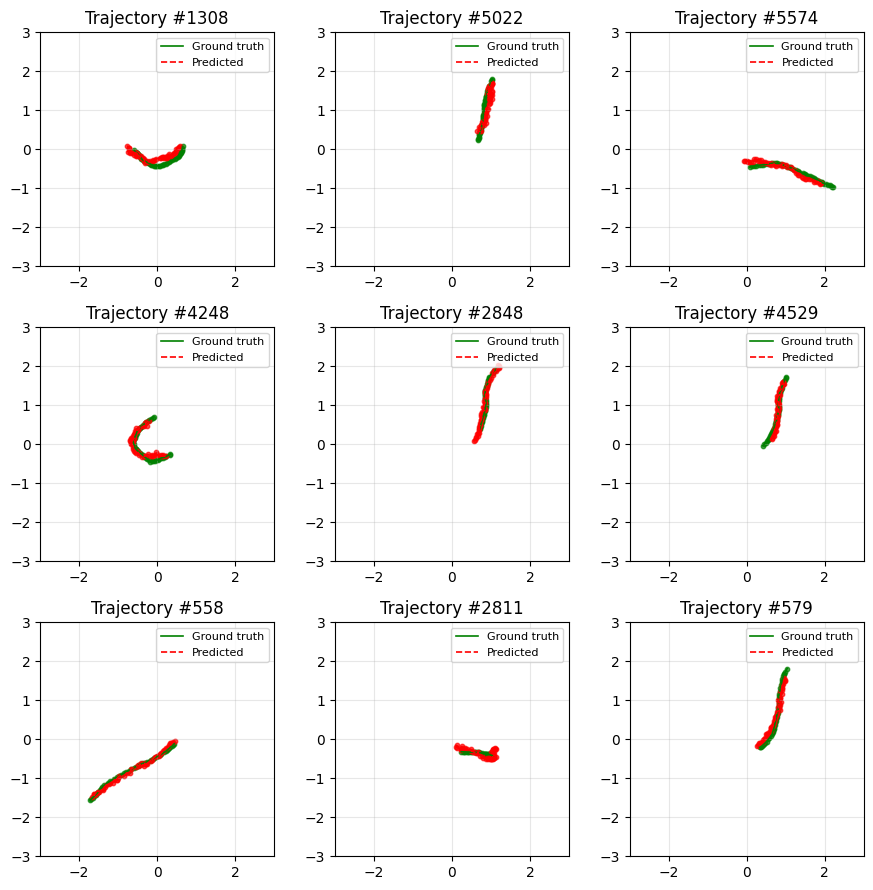

In [ ]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Test_LOSO_set_1')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

100%|██████████| 5/5 [00:00<00:00,  7.76it/s]


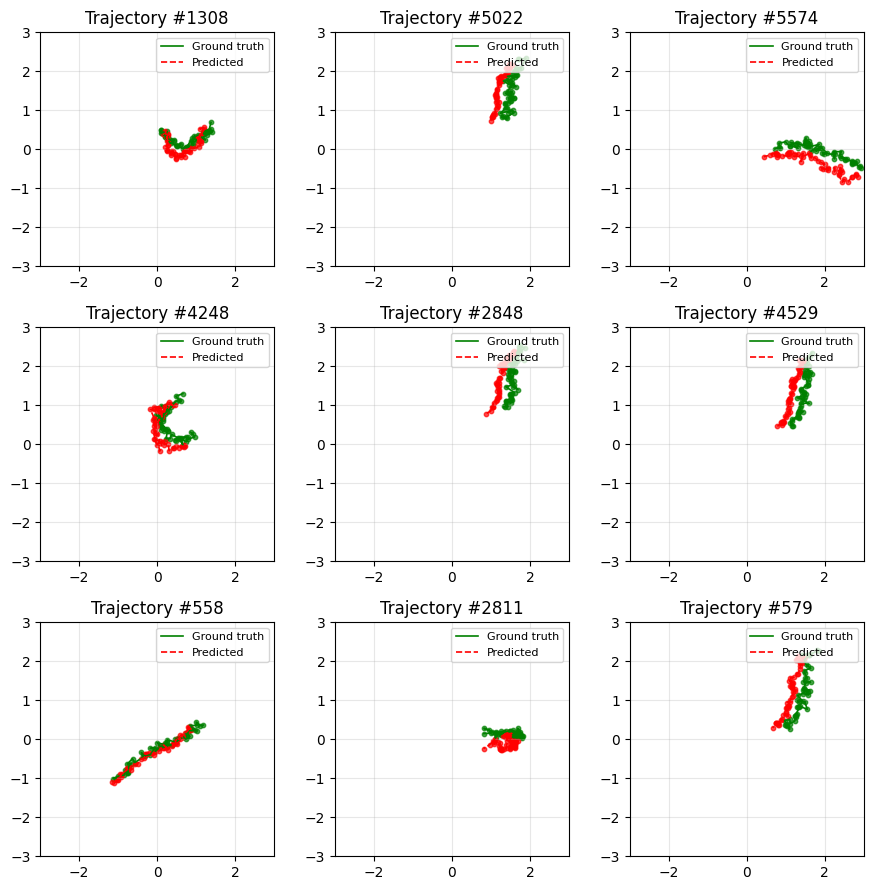

100%|██████████| 5/5 [00:00<00:00,  6.88it/s]


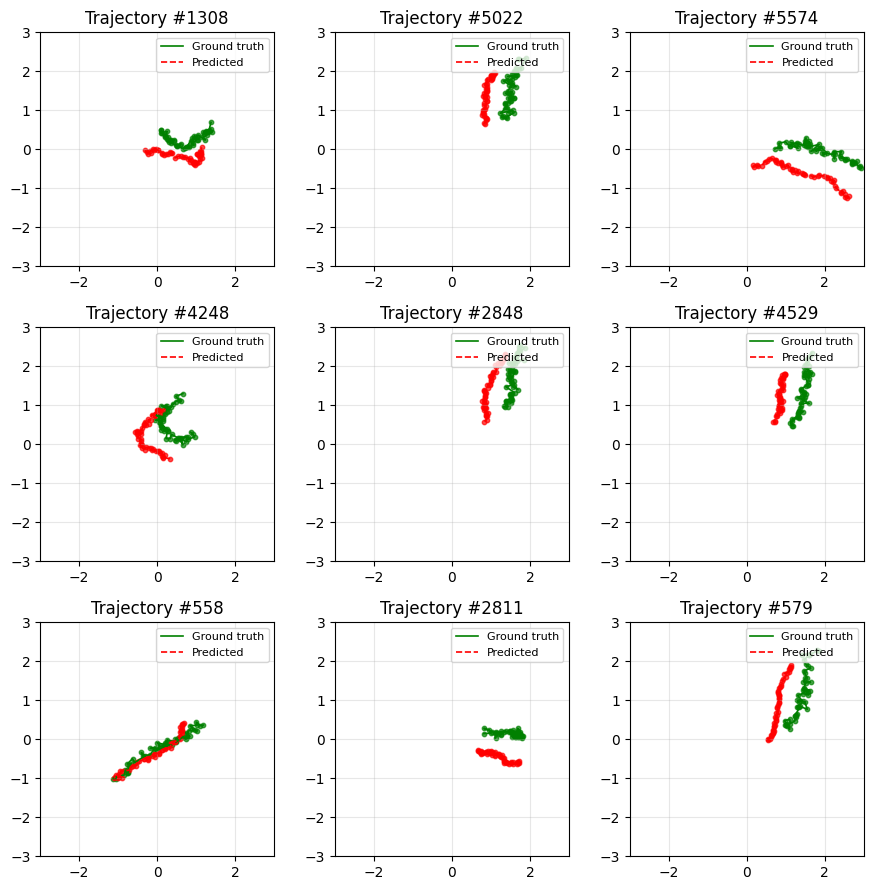

In [ ]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Valid_LOSO_set_1_Random_pos_offset_high')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

100%|██████████| 5/5 [00:00<00:00,  7.41it/s]


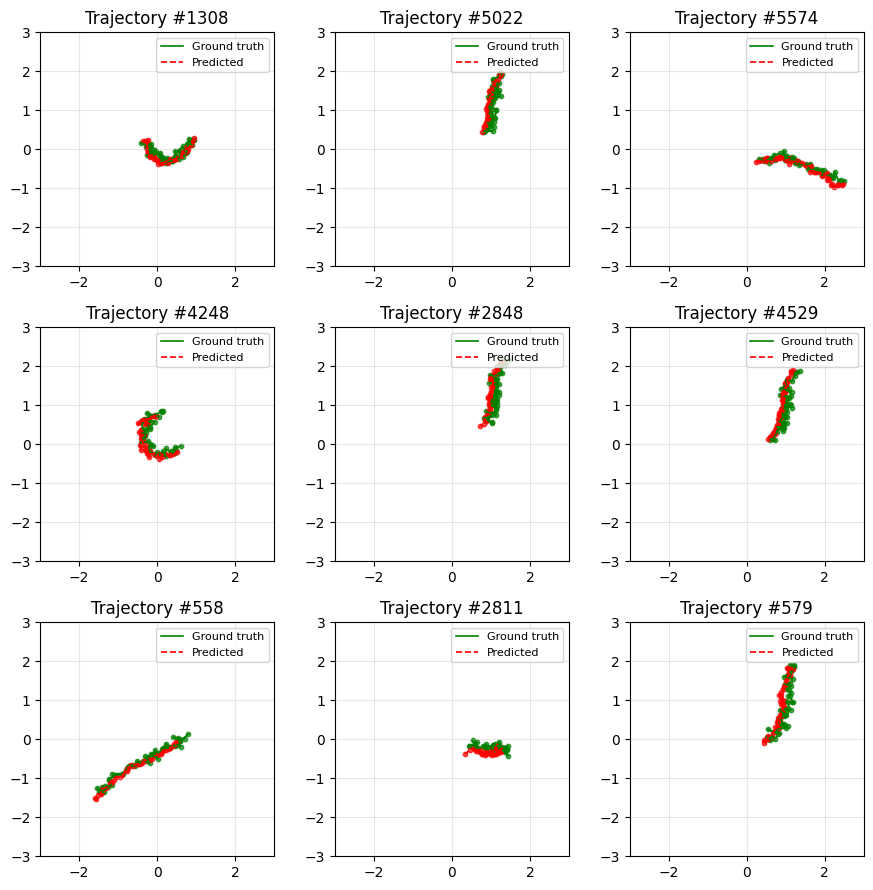

100%|██████████| 5/5 [00:00<00:00,  8.90it/s]


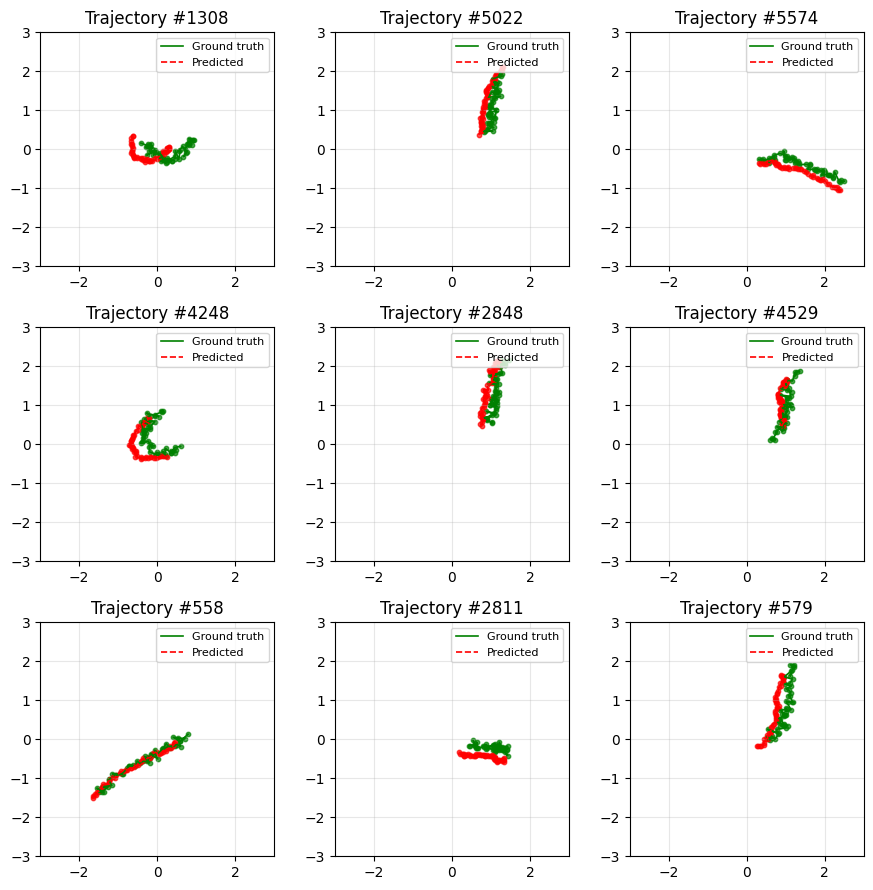

In [ ]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Valid_LOSO_set_1_Random_pos_offset_low')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")

100%|██████████| 5/5 [00:00<00:00,  7.34it/s]


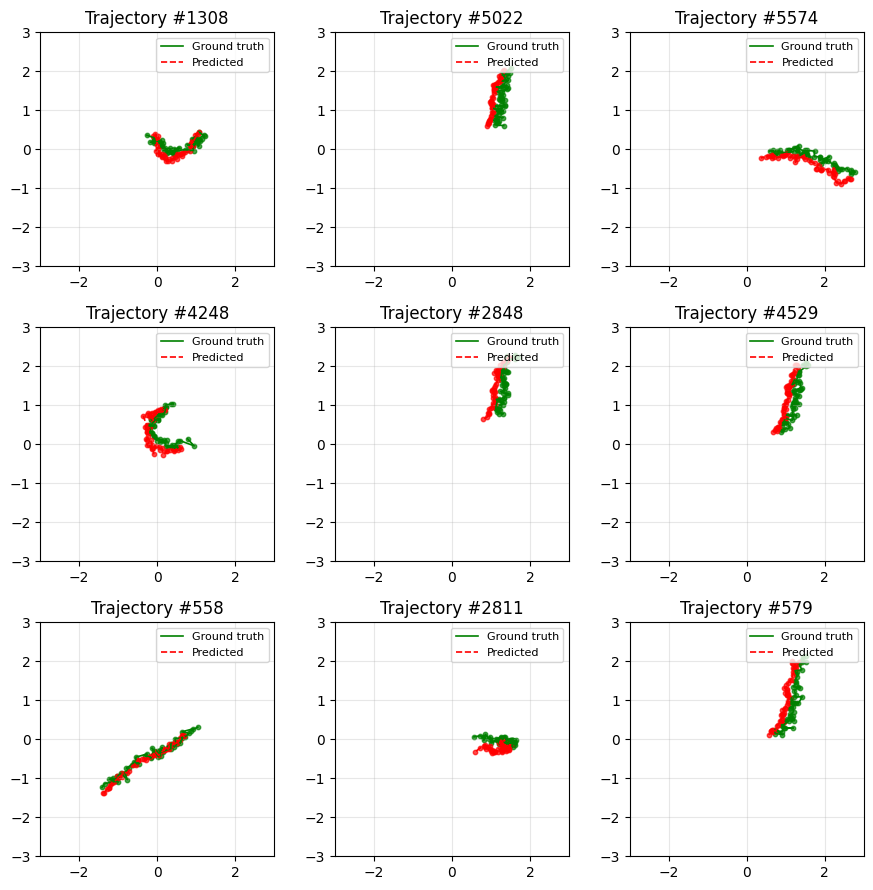

100%|██████████| 5/5 [00:00<00:00,  8.96it/s]


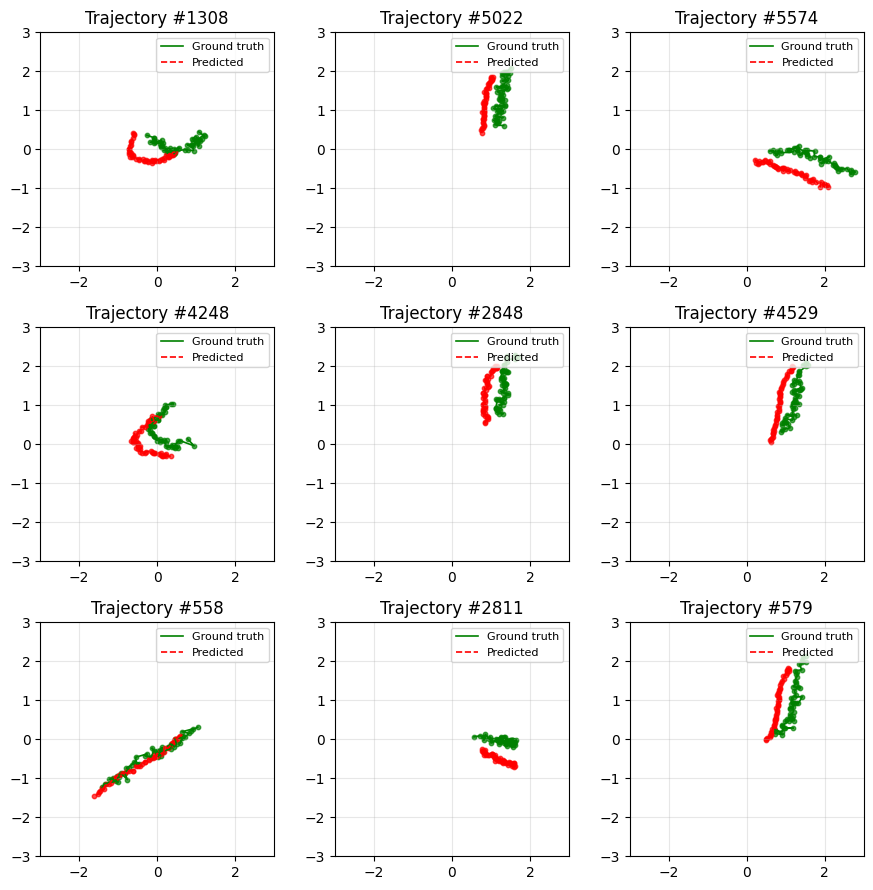

In [ ]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid
from abench.store import api

for component_name in ['ConvAE','ConvVAE']:
    X,y,output,context,metadata=api.get_data_and_output('Results',component_name=component_name,trainset_name='data_Train_LOSO_set_1',set_name='data_Valid_LOSO_set_1_Random_pos_offset_median')
    fig, axes, idx_used = plot_grid(
        plot_fn=plot_trajet,
        y=y,
        output=output,
        context=np.arange(len(output))[:,None],
        metadata=None,
        n=3,
        random_state=42,
        lim=(-3, 3),
        figsize_per_cell=3,
        title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}")